###  Aplinkos paruošimas


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

# For regression:
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

---

### Duomenų įkėlimas


In [24]:
df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


---

### 1. Duomenų supratimas ir paruošimas


Duomenų rinkinio eilučių ir stulpelių skaičius:

In [25]:
df.shape

(1000, 17)

Stulpelių pavadinimai:

In [26]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

Bendra informacija apie duomenis:

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

Duomenų tipai kiekviename stulpelyje:

In [28]:
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Duomenys neturi trūkstamų reikšmių:

In [29]:
df.isna().sum().sort_values(ascending=False)

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Konvertuojama data į `datetime` tipą.
Sukuriamas atskiras datos ir laiko (`Datetime`) stulpelis, iškart po `Date` ir `Time` stulpelių.
Pasirinktinai, `Date` ir `Time` stulpeliai gali būti panaikinti:

In [30]:
df["Date"] = pd.to_datetime(df["Date"])
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"], format="mixed")
df.insert(df.columns.get_loc("Time") + 1, "Datetime", df.pop("Datetime"))
#df = df.drop(columns=["Date", "Time"])  # <- Pasirinktinai

print("Atnaujinti duomenų tipai:\n")
print(df.dtypes)

print("Atnaujinti duomenys:\n")
df.head()

Atnaujinti duomenų tipai:

Invoice ID                            str
Branch                                str
City                                  str
Customer type                         str
Gender                                str
Product line                          str
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[us]
Time                                  str
Datetime                   datetime64[us]
Payment                               str
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object
Atnaujinti duomenys:



,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Datetime,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,2019-01-05 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,2019-03-08 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,2019-03-03 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,2019-01-27 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,2019-02-08 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


Ar nėra pasikartojančių eilučių:

In [31]:
df.duplicated().sum()


np.int64(0)

Ar kategoriniai kintamieji turi logiškas reikšmes:

In [32]:
print(df["Branch"].unique())
print(df["City"].unique())
print(df["Customer type"].unique())
print(df["Gender"].unique())
print(df["Product line"].unique())
print(df["Payment"].unique())


<StringArray>
['Alex', 'Giza', 'Cairo']
Length: 3, dtype: str
<StringArray>
['Yangon', 'Naypyitaw', 'Mandalay']
Length: 3, dtype: str
<StringArray>
['Member', 'Normal']
Length: 2, dtype: str
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str
<StringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str


Trumpas tekstinis aprašymas ir bazinė duomenų apžvalga:

Analizei naudojamas „Supermarket Sales“ duomenų rinkinys, kuriame yra 1000 eilučių ir 17 kintamųjų. Duomenys apima trijų filialų (A, B, C) pardavimus skirtinguose miestuose, klientų tipus, produktų linijas, kainas, kiekius, mokesčius, bendras pardavimo sumas, pelną ir klientų įvertinimus.

Duomenų kokybės vertinimas
Duomenų tipai: Patikrinus duomenų tipus (df.info()), dauguma kintamųjų yra tinkamai suformatuoti. Skaitiniai kintamieji (Unit price, Quantity, Sales, gross income, Rating) yra float arba int, o kategoriniai – object tipo. Stulpelis Date buvo sėkmingai konvertuotas į datetime formatą.

Trūkstamos reikšmės: Duomenyse trūkstamų reikšmių nėra (df.isna().sum() rezultatas visur lygus 0).

Dublikatai: Nerasta jokių pasikartojančių eilučių (df.duplicated().sum() rezultatas lygus 0).

Logika ir klaidos: Patikrinus logines reikšmes, visi finansiniai rodikliai (Sales, gross income, Unit price) yra teigiami, o Quantity (kiekis) visada didesnis už 0. Akivaizdžių duomenų klaidų neaptikta.

Išvada: Duomenų rinkinis yra švarus, pilnas ir parengtas tolesnei analizei bei vizualizacijai.

---

### 2. Aprašomoji analizė (EDA)



Pagrindinės statistinės metrikos:

In [33]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
Date,1000,2019-02-14 00:05:45.600000,2019-01-01 00:00:00,2019-01-24 00:00:00,2019-02-13 00:00:00,2019-03-08 00:00:00,2019-03-30 00:00:00,NaN
Datetime,1000,2019-02-14 15:30:27.480000,2019-01-01 10:39:00,2019-01-24 17:58:45,2019-02-13 17:37:00,2019-03-08 15:29:30,2019-03-30 20:37:00,NaN
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858


Analizei pasirinkta Sales.

In [34]:
df[["Sales"]].describe()


,Sales
count,1000.000000
mean,322.966749
std,245.885335
min,10.678500
25%,124.422375
50%,253.848000
75%,471.350250
max,1042.650000


Pardavimų (Sales) pasiskirstymas:

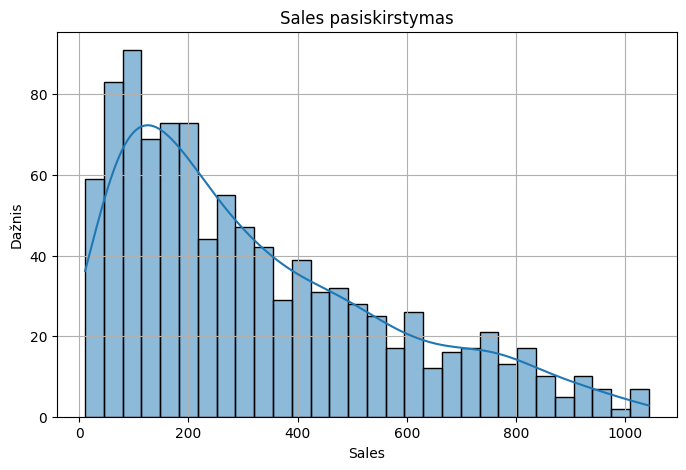

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True, bins=30)
plt.title("Sales pasiskirstymas")
plt.xlabel("Sales")
plt.ylabel("Dažnis")
plt.show()


Interpretacija:  
Sales histograma rodo, kad pardavimų pasiskirstymas yra aiškiai dešinėn pasviręs. Dauguma pirkimų yra mažos arba vidutinės vertės (apie 100–300), o dideli pirkimai virš 800–1000 pasitaiko retai. Tai patvirtina, kad pardavimai turi ilgą dešinę uodegą ir keletą outlierių, kurie kelia vidurkį aukštyn. KDE kreivė rodo vieną ryškų piką ties ~100–150, todėl tipinis pirkimo dydis yra būtent šiame intervale.

Sales pagal Branch:

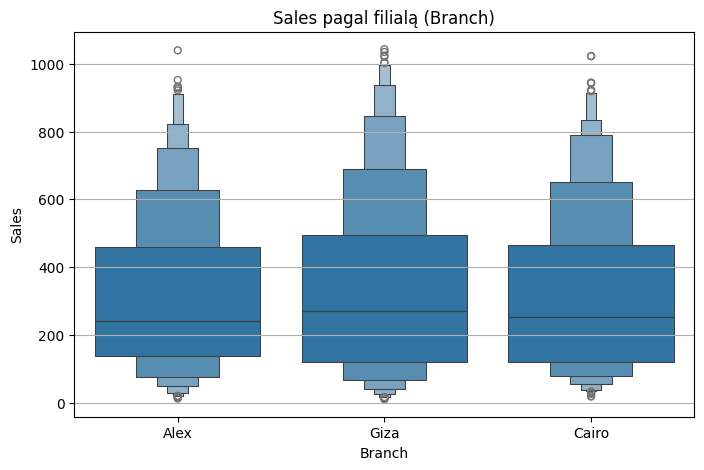

In [36]:
plt.figure(figsize=(8,5))
sns.boxenplot(data=df, x="Branch", y="Sales")
plt.title("Sales pagal filialą (Branch)")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.show()


Interpretacija:  
Boxen grafikas rodo, kad visų trijų filialų (Alex, Giza ir Cairo) pardavimų pasiskirstymas yra labai panašus. Pagrindinė pardavimų dalis (interkvartilinė sritis) yra beveik identiška visuose filialuose, todėl tipinis pirkimo dydis tarp filialų nesiskiria.

Tačiau visuose filialuose matomi išsiskiriantys taškai (outlieriai), kurie atspindi labai didelius pirkimus. Kai kuriuose filialuose (pvz., Cairo) šių didelių pirkimų yra šiek tiek daugiau, todėl jų pardavimų „uodega“ yra ilgesnė. Tai rodo, kad nors vidutiniai pardavimai filialuose panašūs, didelių pirkimų pasitaiko nevienodai.

Vidutiniai Sales pagal Product line:

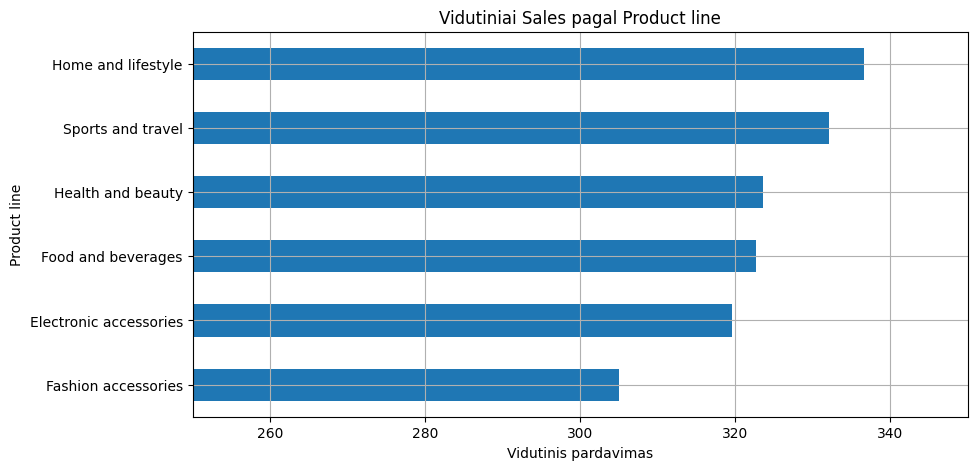

In [37]:
plt.figure(figsize=(10,5))
df.groupby("Product line")["Sales"].mean().sort_values().plot(kind="barh")
plt.title("Vidutiniai Sales pagal Product line")
plt.xlabel("Vidutinis pardavimas")
plt.ylabel("Product line")
plt.xlim(250, 350) 
plt.show()

Interpretacija:  
Iš grafiko matyti, kad didžiausi vidutiniai pardavimai yra „Home and lifestyle“ ir „Sports and travel“ produktų linijose, o mažiausi — „Fashion accessories“. Skirtumai tarp kategorijų nėra labai dideli, tačiau kai kurios linijos generuoja pastebimai didesnę vidutinę pardavimo vertę.

Sales pagal savaitės dienas:

C:\Users\modis\AppData\Local\Temp\ipykernel_6284\3189651765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Weekday", y="Sales", estimator="mean", order=order, palette="rocket")


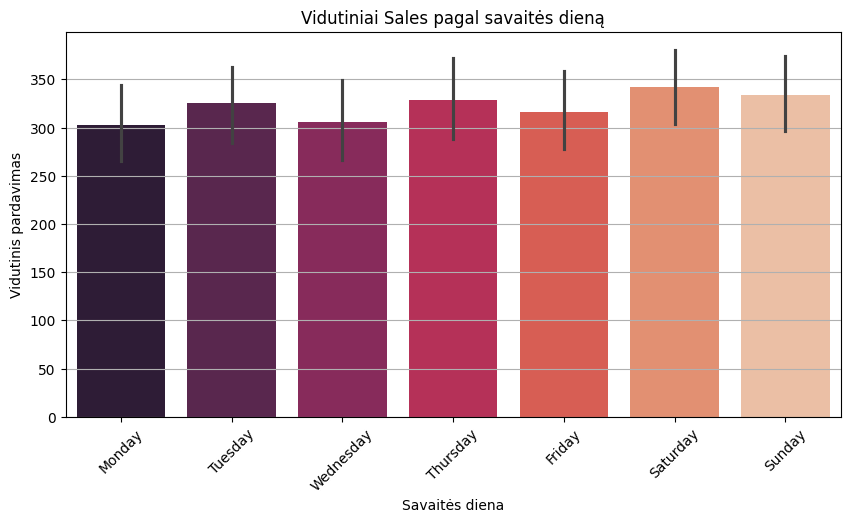

In [38]:
df["Weekday"] = df["Date"].dt.day_name()
plt.figure(figsize=(10,5))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(data=df, x="Weekday", y="Sales", estimator="mean", order=order, palette="rocket")
plt.title("Vidutiniai Sales pagal savaitės dieną")
plt.xlabel("Savaitės diena")
plt.ylabel("Vidutinis pardavimas")
plt.xticks(rotation=45)
plt.show()


Interpretacija:  
Iš grafiko matyti, kad didžiausi vidutiniai pardavimai vyksta savaitgaliais, ypač šeštadienį ir sekmadienį. Mažiausi pardavimai fiksuojami pirmadienį ir trečiadienį. Tai rodo, kad klientų aktyvumas savaitės eigoje nėra tolygus — savaitgaliais pirkėjų srautas ir pirkimų vertė yra didesni.

---

### 3. Pasikliautiniai intervalai



In [39]:
# Pasirenkam kintamąjį
x = df["Sales"]

# Vidurkis
mean = np.mean(x)

# Standartinė paklaida
se = stats.sem(x)

# t kritinė reikšmė (95 % CI, df = n-1)
t_crit = stats.t.ppf(0.95, df=len(x)-1)

# Pasikliautinio intervalo ribos
lower = mean - t_crit * se
upper = mean + t_crit * se

lower, upper


(np.float64(310.165191817398), np.float64(335.768306182602))

Interpretacija:  
95 % CI rodo, kad tikrasis vidutinis pardavimas yra tarp 310 ir 336. Tai intervalas, kuriame su didele tikimybe yra tikrasis vidurkis.

---

### 4. Hipotezių testavimas



In [40]:
# Atskiriame grupes pagal kliento tipą
members_sales = df[df['Customer type'] == 'Member']['Sales']
normal_sales = df[df['Customer type'] == 'Normal']['Sales']

# Atliekame Independent Samples t-test
t_stat, p_value = stats.ttest_ind(members_sales, normal_sales)

# Apskaičiuojame vidurkius praktiniam efektui įvertinti
avg_member = members_sales.mean()
avg_normal = normal_sales.mean()
difference = avg_member - avg_normal

print(f"Narių vidurkis: {avg_member:.2f}")
print(f"Paprastų pirkėjų vidurkis: {avg_normal:.2f}")
print(f"Skirtumas: {difference:.2f}")
print(f"t-statistika: {t_stat:.4f}")
print(f"p-reikšmė: {p_value:.4f}")

Narių vidurkis: 335.74
Paprastų pirkėjų vidurkis: 306.37
Skirtumas: 29.37
t-statistika: 1.8750
p-reikšmė: 0.0611


Interpretacija:
Mūsų analizė rodo, kad nariai vidutiniškai išleidžia 29.37 USD daugiau nei paprasti pirkėjai. Nors p-reikšmė (0.0611) yra šiek tiek virš standartinės 0.05 ribos, skirtumas yra pakankamai pastebimas, kad būtų laikomas verslo tendencija.

In [41]:
# Patikriname, kokios realios reikšmės yra Branch stulpelyje
unique_branches = df['Branch'].unique()
print(f"Rasti filialai: {unique_branches}")

# Dinamiškai sugrupuojame duomenis ANOVA testui
groups = [df[df['Branch'] == branch]['Sales'] for branch in unique_branches]

# Atliekame One-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

# Parodome vidurkius kiekvienam filialui
for branch in unique_branches:
    branch_avg = df[df['Branch'] == branch]['Sales'].mean()
    print(f"Filialo {branch} vidurkis: {branch_avg:.2f}")

print(f"---")
print(f"F-statistika: {f_stat:.4f}")
print(f"p-reikšmė: {p_value:.4f}")

Rasti filialai: <StringArray>
['Alex', 'Giza', 'Cairo']
Length: 3, dtype: str
Filialo Alex vidurkis: 312.35
Filialo Giza vidurkis: 337.10
Filialo Cairo vidurkis: 319.87
---
F-statistika: 0.8846
p-reikšmė: 0.4132


Iterpratacija:
 Nėra statistiškai reikšmingo skirtumo tarp filialų „Alex“, „Giza“ ir „Cairo“ vidutinių pardavimų. Skirtumai, kuriuos matome tarp vidurkių, greičiausiai atsirado dėl atsitiktinių svyravimų, o ne dėl to, kad vienas filialas dirba geriau už kitus.

In [42]:
# Sukuriame dažnių lentelę (Contingency Table)
contingency_table = pd.crosstab(df['Gender'], df['Payment'])

# Atliekame Chi-square testą
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Dažnių lentelė:")
print(contingency_table)
print(f"\n---")
print(f"Chi-square statistika: {chi2:.4f}")
print(f"p-reikšmė: {p_value:.4f}")
print(f"Laisvės laipsniai: {dof}")

Dažnių lentelė:
Payment  Cash  Credit card  Ewallet
Gender                             
Female    205          183      183
Male      139          128      162

---
Chi-square statistika: 3.5758
p-reikšmė: 0.1673
Laisvės laipsniai: 2


Interpretacija: Ryšys tarp pirkėjo lyties ir pasirinkto mokėjimo būdo nėra statistiškai reikšmingas. Tai reiškia, kad pasirinkimas mokėti grynais, kortele ar elektronine pinigine nepriklauso nuo to, ar pirkėjas yra vyras, ar moteris.

---

### 5. Analitinė dalis

### 5.A. Regresinė analizė


In [43]:
# 1. Pasirinkti target kintamąjį
y = df["Sales"]

# 2. Pasirinkti features (5–8)
features = [
    "Unit price",
    "Quantity",
    "Rating",
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Payment"
]
X = df[features]

# 3. Kategorinius kintamuosius paversti į dummy
X = pd.get_dummies(X, drop_first=True)

# SVARBU OLS modeliui
X = X.astype(float)

# 4. Padalinti duomenis į mokymo ir testavimo rinkinius (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# 5. Pridėti constant OLS modeliui
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 6. Sukurti ir apmokyti regresijos modelį
model = sm.OLS(y_train, X_train_sm).fit()

# 7. Modelio santrauka
print(model.summary())

# 8. Prognozės testavimo rinkinyje
y_pred = model.predict(X_test_sm)

# 9. Modelio kokybės įvertinimas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print("\nModelio vertinimas:")
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     692.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:28:42   Log-Likelihood:                -4656.2
No. Observations:                 800   AIC:                             9332.
Df Residuals:                     790   BIC:                             9379.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -216.9206 

Interpretacija:
Modelio rezultatai rodo, kad didžiausią įtaką pardavimams (Sales) turi Quantity ir Unit price, nes didėjant perkamų vienetų kiekiui ir produkto kainai, bendra pardavimo suma taip pat didėja. Modelio R² reikšmė rodo, kad modelis gana gerai paaiškina pardavimų pokyčius, todėl pasirinkti kintamieji yra tinkami prognozuoti pardavimus

---

### 5.B. Laiko eilučių analizė



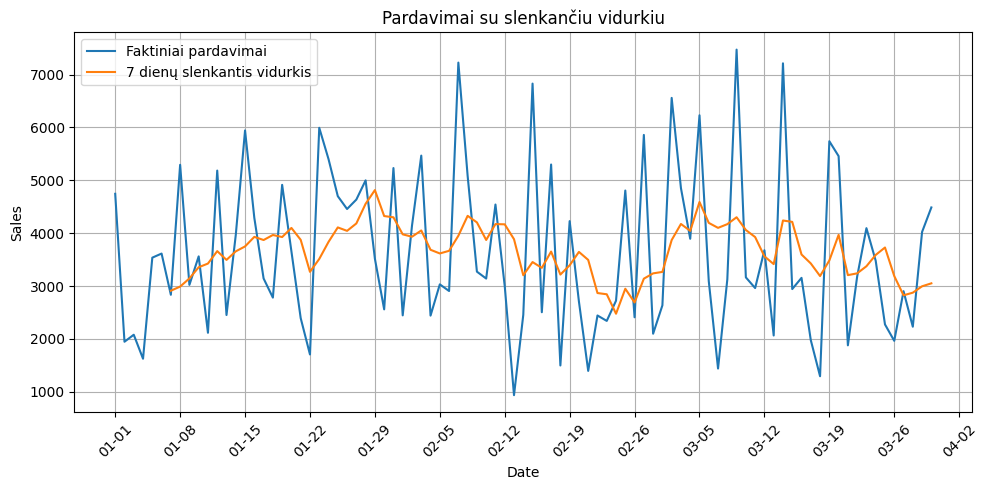

Prognozė pagal paskutinių 7 dienų vidurkį: 3050.78


In [45]:
# Sukurti laiko eilutę
sales_time = df.groupby("Date")["Sales"].sum().sort_index()

# Apskaičiuoti slenkantį vidurkį
moving_avg = sales_time.rolling(window=7).mean()

# Grafikas – pardavimų dinamika
plt.figure(figsize=(10,5))
plt.plot(sales_time, label="Faktiniai pardavimai")
plt.plot(moving_avg, label="7 dienų slenkantis vidurkis")

plt.title("Pardavimai su slenkančiu vidurkiu")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Paprasta prognozė
forecast = sales_time.tail(7).mean().round(2)
print("Prognozė pagal paskutinių 7 dienų vidurkį:", forecast)

Interpretacija: Faktiniai pardavimai labai svyruoja dienomis, tačiau 7 dienų slenkantis vidurkis išlygina šiuos šuolius ir parodo aiškesnę bendrą tendenciją. Matyti, kad pardavimai laikotarpiu iš esmės išlieka stabilūs, su keliais ryškesniais pakilimo taškais, kurie išsiskiria virš vidurkio linijos.